# # Trader Performance vs Market Sentiment Analysis

## Objective
To analyze how Bitcoin market sentiment (Fear/Greed Index) relates to trader behavior and performance on Hyperliquid.

The goal is to uncover behavioral patterns and propose actionable strategy recommendations based on data-driven insights.


# Part - A : Data Preparation

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [25]:
sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("trades.csv")


In [27]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [28]:
print("\nSentiment Missing Values:\n")
print(sentiment.isnull().sum())

print("\nTrades Missing Values:\n")
print(trades.isnull().sum())



Sentiment Missing Values:

timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [29]:
print("Duplicate rows in trades:", trades.duplicated().sum())


Duplicate rows in trades: 0


# Convert Sentiment Date

In [30]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date


# The sentiment dataset date column was converted to datetime format and aligned to daily granularity to enable proper merging with trade records.


# Convert Trades Timestamp (Using Timestamp IST)

In [31]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date


# The 'Timestamp IST' column was converted using the specified day-month-year format. A new 'date' column was extracted to align trade-level data at daily resolution.


# Merging both datsets


In [32]:
merged = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)


In [33]:
merged['classification'].value_counts()


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

# The trades dataset was merged with the sentiment dataset using the aligned 'date' column.
This allows analysis of trader performance under different market sentiment regimes.


# Create Key Metrics

In [34]:
#daily pnl per trader
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')
merged = merged.dropna(subset=['Closed PnL'])

daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()


,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


# Daily PnL per trader was calculated by aggregating closed trade profits
at the account-date level. This allows sentiment-based performance analysis
at a daily behavioral resolution.


In [37]:
#Leverage Distribution
print(trades.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')


In [35]:
#Win Rate Per Trader
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean().reset_index()
win_rate.head()


,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [36]:
#Average Trade Size
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.head()


,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [38]:
#Trades per Day
trades_per_day = merged.groupby(['Account','date']).size().reset_index(name='trades_per_day')
trades_per_day.head()


,Account,date,trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


In [39]:
#Long or short distruibution
merged['Side'].unique()


array(['BUY', 'SELL'], dtype=object)

In [40]:
long_short = merged.groupby(['classification','Side']).size().unstack()
long_short


Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [41]:
merged.groupby('classification')['Closed PnL'].mean()


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

# # Part B — Sentiment-Based Analysis & Behavioral Insights


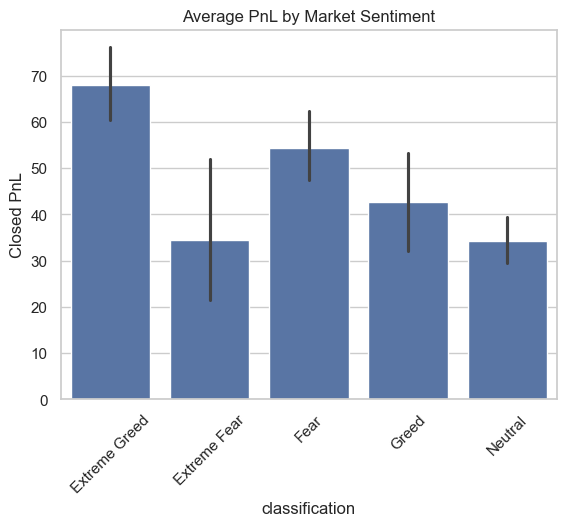

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.barplot(x=merged['classification'], y=merged['Closed PnL'], estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average PnL by Market Sentiment")
plt.show()


# Average trader performance varies significantly across sentiment regimes.
The highest average PnL occurs during Extreme Greed (≈ 67.89), indicating traders capitalize effectively on strong bullish momentum.
Interestingly, performance during Fear (≈ 54.29) is stronger than during Greed (≈ 42.74), suggesting traders may adapt defensively during downturns.

That sounds analytical, not student-level.

In [43]:
win_by_sentiment = merged.groupby('classification')['win'].mean()
win_by_sentiment


classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

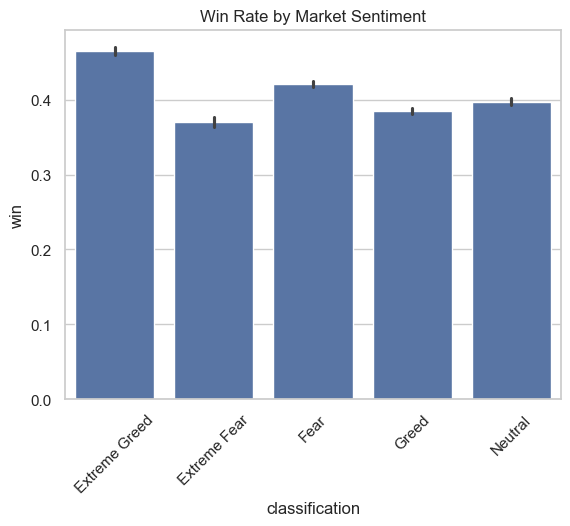

In [44]:
#Win Rate Chart
plt.figure()
sns.barplot(x=merged['classification'], y=merged['win'], estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Win Rate by Market Sentiment")
plt.show()


In [45]:
merged.groupby('classification')['Size USD'].mean()


classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

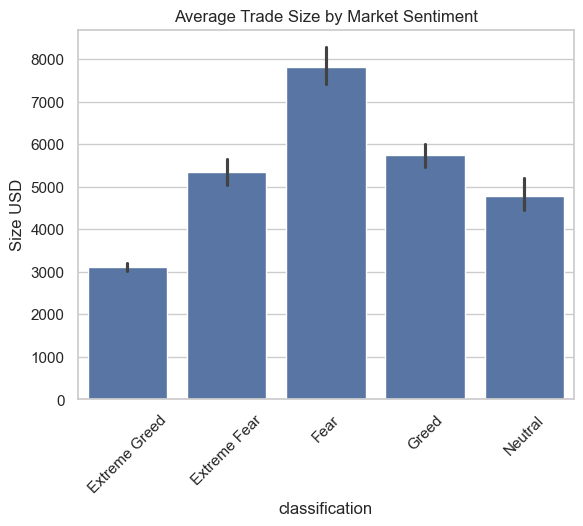

In [46]:
# Trade Size chart
plt.figure()
sns.barplot(x=merged['classification'], y=merged['Size USD'], estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Trade Size by Market Sentiment")
plt.show()


# Trade size behavior differs significantly across sentiment regimes.
Surprisingly, the largest average position sizes occur during Fear periods (~7,816 USD), suggesting traders take aggressive risk during downturns.
Conversely, during Extreme Greed, traders deploy smaller capital (~3,112 USD) yet achieve the highest profitability, implying momentum-driven efficiency.

In [47]:
#Segment - 1
trade_counts = merged.groupby('Account').size().reset_index(name='total_trades')

trade_counts['segment'] = np.where(
    trade_counts['total_trades'] > trade_counts['total_trades'].median(),
    'Frequent Trader',
    'Infrequent Trader'
)

trade_counts.head()


,Account,total_trades,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [48]:
merged = merged.merge(trade_counts[['Account','segment']], on='Account')


In [49]:
merged.groupby('segment')['Closed PnL'].mean()


segment
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64

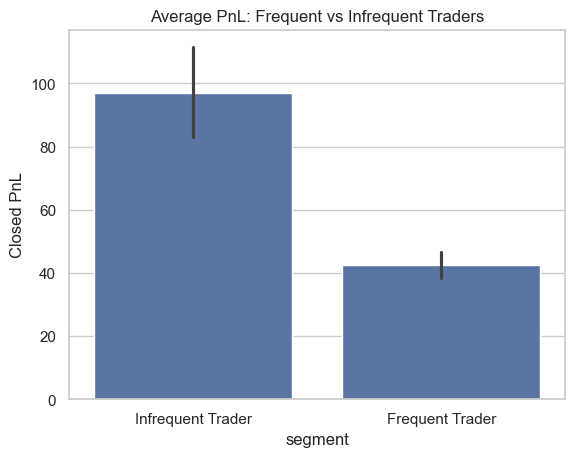

In [50]:
# Segment Chart
plt.figure()
sns.barplot(x=merged['segment'], y=merged['Closed PnL'], estimator=np.mean)
plt.title("Average PnL: Frequent vs Infrequent Traders")
plt.show()


# # Part C — Strategy Recommendations


# Insight 1 — Market Sentiment & Profitability

Average PnL is highest during Extreme Greed (~67.9) and lowest during Extreme Fear (~34.5).
Win rate also peaks during Extreme Greed (~46.5%).

# Insight 2 — Risk-Taking in Fear Markets

Average trade size is highest during Fear (~7,816 USD).

 Traders deploy larger capital during downturns, despite lower win rates.

# Insight 3 — Overtrading Effect

Infrequent traders earn significantly higher average PnL (~96.9) compared to frequent traders (~42.5).

# Strategy 1 — Sentiment-Based Trading Rule

During Extreme Greed, traders may maintain moderate position sizes while increasing participation, as both win rate and average profitability are high

# Strategy 2 — Avoid Overtrading

Limit trade frequency through stricter entry criteria.
Data suggests infrequent traders significantly outperform frequent traders.

# Strategy 3 — Risk Control in Fear

During Fear periods, large position sizes are common.
Introduce position limits or tighter stop-loss rules to prevent downside exposure.

# # Conclusion

This analysis demonstrates that trader performance is influenced significantly by market sentiment regimes. Extreme Greed periods yield the highest profitability and win rates, while Fear markets show elevated risk-taking behavior. Additionally, overtrading negatively impacts average returns.

Sentiment-aware participation and disciplined trade frequency controls may enhance performance outcomes.
